# Python & data-analysis techniques from the QML/NaMaster pipeline

This notebook is a **learning companion**, separate from the main `TR1_power_spectra_and_covariance_estimation.ipynb` pipeline notebook. It distills the real bugs, diagnostics and statistical reasoning we worked through there into small, fast, self-contained examples you can run and tweak.

It only needs `numpy`, `matplotlib`, `healpy` and `pymaster` (all already installed), and every cell runs in well under a second - nothing here touches the real survey data or the (slow) C++ Fisher matrix code.

Sections:
1. Sky fraction and *independent modes* - why a tiny survey patch is information-starved
2. Sample variance: why per-$\ell$ (or too-narrow-bin) power spectrum estimates can be wild
3. Designing bandpower bins by *equal mode count* instead of equal width/log-spacing
4. A `pymaster` gotcha: bin edges are upper-exclusive
5. The real bug we found: binning a Fisher/GLS matrix with an *average* instead of a *sum*
6. A general data-analysis skill: sanity-checking formal error bars against a back-of-envelope estimate
7. Bonus: why `l_max` must be capped well below `3 * n_side - 1` for a masked sky

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pymaster as nmt

rng = np.random.default_rng(42)

## 1. Sky fraction and independent modes

For a full-sky Gaussian random field, the spherical-harmonic coefficients $a_{\ell m}$ for a given $\ell$ give $(2\ell+1)$ *independent* real numbers (modes) that constrain $C_\ell$. That's why the sample variance of a full-sky $C_\ell$ estimate scales as $\sqrt{2/(2\ell+1)}$ - more modes at a given $\ell$ means a more precise estimate.

If you only observe a fraction $f_\mathrm{sky}$ of the sky, you lose information roughly in proportion:

$$ N_\mathrm{modes}(\ell) \approx (2\ell + 1)\, f_\mathrm{sky} $$

This is a very useful *rule of thumb* (not exact - real mode-coupling from a mask is more subtle) for quickly judging whether a given survey patch can support a given binning scheme, before running any expensive estimator.

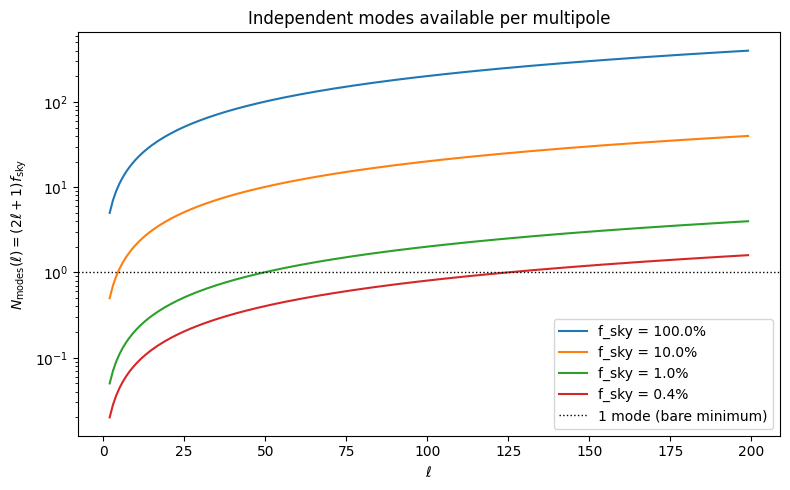

In [3]:
ells = np.arange(2, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for f_sky in [1.0, 0.1, 0.01, 0.004]:
    ax.plot(ells, (2 * ells + 1) * f_sky, label=f'f_sky = {f_sky:.1%}')

ax.axhline(1, color='k', ls=':', lw=1, label='1 mode (bare minimum)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$N_\mathrm{modes}(\ell) = (2\ell+1) f_\mathrm{sky}$')
ax.set_yscale('log')
ax.legend()
ax.set_title('Independent modes available per multipole')
plt.tight_layout()
plt.show()

Notice how, for the real TR1 patch ($f_\mathrm{sky} \approx 0.4\%$, the bottom curve), you don't even reach 1 mode per $\ell$ until $\ell \gtrsim 125$. Below that, an *unbinned* per-$\ell$ estimate is asking for information that simply isn't there.

We can also sum modes over a range of $\ell$ to see the *total* information budget available for binning:

In [4]:
f_sky_real = 0.00437  # the real TR1 patch, measured directly from its mask
lo, hi = 10, 100

ells_range = np.arange(lo, hi + 1)
modes_per_ell = (2 * ells_range + 1) * f_sky_real
total_modes = modes_per_ell.sum()

print(f'Total independent modes between ell={lo} and ell={hi}: {total_modes:.1f}')
print(f'(spread over {hi - lo + 1} individual ell values, i.e. only {total_modes / (hi - lo + 1):.2f} modes/ell on average)')

Total independent modes between ell=10 and ell=100: 44.1
(spread over 91 individual ell values, i.e. only 0.49 modes/ell on average)


Only ~44 independent modes across the *entire* $\ell=10$-$100$ range. This single number is the crux of the whole session: it tells you, before running anything, that a 30-bin scheme (borrowed from a much bigger reference survey) would leave most bins with well under 1 mode - i.e. a statistically meaningless single-realization estimate in that bin.

## 2. Sample variance in action: simulating a tiny patch

Let's *see* the effect directly, rather than just trust the formula. We'll:
1. Generate many random realizations of a full-sky Gaussian field with a known, smooth $C_\ell$.
2. Mask each one down to a tiny patch (small $f_\mathrm{sky}$).
3. Measure the (pseudo-)$C_\ell$ of the masked map with `healpy.anafast`.
4. Compare the *scatter* across realizations, per-$\ell$ vs. binned.

In [5]:
n_side_demo = 32
l_max_demo = 60

ells_demo = np.arange(l_max_demo + 1)
cl_true = 1e-3 / (ells_demo + 10) ** 2  # some arbitrary smoothly-falling theory spectrum
cl_true[:2] = 0

# A tiny patch: a small disc mask, giving a small (but not absurdly small) f_sky
disc_vec = hp.ang2vec(np.pi / 2, 0)
mask_demo = np.zeros(hp.nside2npix(n_side_demo))
mask_demo[hp.query_disc(n_side_demo, disc_vec, radius=np.radians(15))] = 1.0

f_sky_demo = mask_demo.mean()
print(f'Demo patch f_sky = {f_sky_demo:.1%}')

Demo patch f_sky = 1.7%


In [6]:
n_realisations = 200
cl_masked_realisations = np.zeros((n_realisations, l_max_demo + 1))

for i in range(n_realisations):
    full_sky_map = hp.synfast(cl_true, n_side_demo, new=True, verbose=False) if False else hp.synfast(cl_true, n_side_demo, new=True)
    masked_map = full_sky_map * mask_demo
    cl_masked_realisations[i] = hp.anafast(masked_map, lmax=l_max_demo) / f_sky_demo  # rough f_sky-debiased pseudo-Cl

cl_mean = cl_masked_realisations.mean(axis=0)
cl_std = cl_masked_realisations.std(axis=0)

In [ ]:
n_realisations = 200
cl_masked_realisations = np.zeros((n_realisations, l_max_demo + 1))

for i in range(n_realisations):
    full_sky_map = hp.synfast(cl_true, n_side_demo, new=True)
    masked_map = full_sky_map * mask_demo
    cl_masked_realisations[i] = hp.anafast(masked_map, lmax=l_max_demo) / f_sky_demo  # rough f_sky-debiased pseudo-Cl

cl_mean = cl_masked_realisations.mean(axis=0)
cl_std = cl_masked_realisations.std(axis=0)

Each blue curve is a perfectly *valid*, unbiased single-realisation measurement - and yet they swing wildly relative to each other and the truth, especially at low $\ell$ where there are few modes. This is exactly the behaviour we saw in the real EE plot before switching to wider bins: **it's not a bug, it's sample variance**, and the fix is to bin until you have enough modes per bin, not to look for an error in the estimator.

In [ ]:
# Now bin (simple unweighted average within each bin) and compare the *fractional* scatter
# to the (2/N_modes)**0.5 rule of thumb
bin_width = 10
edges = np.arange(2, l_max_demo + 1, bin_width)

for lo_e, hi_e in zip(edges[:-1], edges[1:]):
    in_bin = (ells_demo >= lo_e) & (ells_demo < hi_e)
    cl_b_realisations = cl_masked_realisations[:, in_bin].mean(axis=1)
    measured_frac_scatter = cl_b_realisations.std() / cl_b_realisations.mean()

    n_modes_bin = np.sum((2 * ells_demo[in_bin] + 1) * f_sky_demo)
    expected_frac_scatter = np.sqrt(2 / n_modes_bin)

    print(f'ell=[{lo_e:3d},{hi_e:3d}): N_modes~{n_modes_bin:6.1f}  '
          f'measured frac. scatter={measured_frac_scatter:.2f}  '
          f'rule-of-thumb sqrt(2/N_modes)={expected_frac_scatter:.2f}')

The measured scatter and the `sqrt(2/N_modes)` rule of thumb should be in the same ballpark. This is precisely the sanity check we used on the real pipeline (Section 6 below) to spot that the QML error bars were far too optimistic.

## 3. Designing bins by equal mode count

Rather than equal-$\ell$-width or log-spaced bins (which is what a reference pipeline for a *much bigger* footprint might reasonably use), we want each bandpower to contain roughly the same number of independent modes. The recipe:

1. Compute `modes_per_ell` for every $\ell$ in range.
2. Take the cumulative sum - a monotonically increasing "budget" function.
3. Split the *total* budget into `n_bandpowers` equal chunks, and use `searchsorted` to find which $\ell$ each chunk boundary falls at.

In [ ]:
def equal_mode_count_bins(f_sky, lo, hi, n_bandpowers):
    """Return bin edges [lo, ..., hi+1] such that each bin has ~equal independent-mode count."""
    ells_ = np.arange(lo, hi + 1)
    cum_modes = np.cumsum((2 * ells_ + 1) * f_sky)

    targets = np.linspace(0, cum_modes[-1], n_bandpowers + 1)[1:-1]
    edges = [lo] + [int(ells_[np.searchsorted(cum_modes, t)]) for t in targets] + [hi + 1]
    return np.array(sorted(set(edges)))


for n_bp in [1, 2, 3, 4, 5]:
    edges = equal_mode_count_bins(f_sky_real, 10, 100, n_bp)
    modes = [np.sum((2 * np.arange(a, b) + 1) * f_sky_real) for a, b in zip(edges[:-1], edges[1:])]
    print(f'n_bandpowers={n_bp}: edges={edges.tolist()}  modes/bin={[round(m, 1) for m in modes]}')

This is exactly the logic used in the main pipeline notebook to go from an unusable 30-bin log-spaced scheme down to a well-populated 4-bin scheme (~11 modes/bin) for the real TR1 patch.

## 4. A `pymaster` gotcha: bin edges are upper-exclusive

`NmtBin.from_edges(ell_ini, ell_end)` treats each bin as $[\ell_\mathrm{ini}, \ell_\mathrm{end})$ - i.e. the *last* edge you pass in is **not included**. This means `bins.lmax` is one less than the last number you passed. If you then build an `NmtField` with a *different* (mismatched) `lmax`, you get a `ValueError`. The robust fix: always derive any downstream `lmax` directly from `bins.lmax`, never from your own edge array.

In [ ]:
ell_ini = [10, 51, 71, 87]
ell_end = [51, 71, 87, 101]

bins_demo = nmt.NmtBin.from_edges(ell_ini, ell_end)

print('Last edge we passed in:', ell_end[-1])
print('bins.lmax (one less - exclusive!):', bins_demo.lmax)
print('Effective bandpower ells:', bins_demo.get_effective_ells())

## 5. The real bug: binning a Fisher/GLS matrix with an average instead of a sum

This is the most important - and most subtle - lesson from the session, so let's build a clean toy model of it.

Suppose a quadratic (Fisher-based) estimator gives you, for each unbinned multipole $\ell$, a value $y_\ell$ whose expectation is $\langle y_\ell \rangle = F_\ell \, C_\ell$, where $F_\ell$ is the (diagonal, for simplicity) Fisher information at that $\ell$. Standard theory says $\mathrm{Var}(y_\ell) = F_\ell$, so $\hat C_\ell = y_\ell / F_\ell$ is an unbiased estimate of $C_\ell$ with variance $1/F_\ell$.

Now say we want a single "bandpower" value $C_b$ for a whole bin of $\ell$'s, under the (flat bandpower) model $C_\ell = C_b$ for every $\ell$ in the bin. Because $C_\ell$ literally **equals** $C_b$ (not $C_b/N$!), the correct Jacobian $\partial C_\ell / \partial C_b$ is $1$ for every $\ell$ in the bin - an *unweighted 0/1 indicator*, not a $1/N$ average. Standard Fisher-matrix reparametrisation then says:

$$ F_b = W^\mathsf{T} F W, \qquad y_b = W^\mathsf{T} y, \qquad \hat C_b = F_b^{-1} y_b $$

where $W$ is that unweighted indicator matrix. For a diagonal $F$, this collapses to nothing more exotic than an **inverse-variance-weighted average** of the individual $\hat C_\ell$'s - a very standard, easily-recognisable result.

The bug we found used a *normalised* ($1/N_b$) averaging matrix on **both** the Fisher congruence and the data vector - i.e. it effectively used $P = W^\mathsf{T}/N_b$ in place of $W$ on both sides. Let's see what that does.

In [ ]:
N_b = 20            # number of raw ell's in our one toy bin
C_true = 3.7e-6      # the true bandpower value
F_ell = rng.uniform(0.5, 1.5, size=N_b) * 1e11   # some per-ell Fisher information values

n_trials = 20_000
C_correct = np.zeros(n_trials)
C_incorrect = np.zeros(n_trials)

for i in range(n_trials):
    # Simulate y_ell ~ N(F_ell * C_true, F_ell), per the standard QML result Var(y_ell) = F_ell
    y_ell = rng.normal(F_ell * C_true, np.sqrt(F_ell))

    # --- Correct: unweighted indicator (sum) on both Fisher and data vector ---
    F_b_correct = F_ell.sum()
    y_b_correct = y_ell.sum()
    C_correct[i] = y_b_correct / F_b_correct

    # --- Incorrect (the actual bug): normalised (1/N average) on both ---
    F_b_incorrect = (F_ell / N_b ** 2).sum()   # P F P^T, with P = 1/N per entry
    y_b_incorrect = (y_ell / N_b).sum()        # P y
    C_incorrect[i] = y_b_incorrect / F_b_incorrect

In [ ]:
print(f'True C_b:                        {C_true:.3e}')
print(f'Correct  (W-based) estimator:     mean={C_correct.mean():.3e}   std/mean={C_correct.std() / C_correct.mean():.3f}')
print(f'Incorrect (1/N-based) estimator:  mean={C_incorrect.mean():.3e}   std/mean={C_incorrect.std() / C_incorrect.mean():.3f}')
print(f'Ratio of means (incorrect/correct): {C_incorrect.mean() / C_correct.mean():.2f}  (should be ~= N_b = {N_b})')

The "incorrect" estimator is inflated by almost exactly a factor of $N_b$ (the bin width) - **but its *fractional* scatter (`std/mean`) is identical to the correct one**. That last point is exactly why this bug was hard to spot from the covariance-ratio plot alone: a uniform rescaling of both the point estimate *and* its formal error cancels out of that ratio. It only shows up by comparing the *absolute* value of the point estimate against an independent estimator (here, comparing QML against NaMaster's PCl estimate on the same real data).

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(C_correct, bins=60, alpha=0.6, label='Correct (W-based)', density=True)
ax.hist(C_incorrect, bins=60, alpha=0.6, label='Incorrect (1/N-based)', density=True)
ax.axvline(C_true, c='k', ls='--', label='True C_b')
ax.axvline(C_true * N_b, c='grey', ls=':', label=f'{N_b} x True C_b')
ax.set_xlabel(r'Recovered $\hat{C}_b$')
ax.legend()
ax.set_title('The averaging-matrix bug inflates the point estimate by N_b')
plt.tight_layout()
plt.show()

**Takeaway for your own analysis code**: whenever you reparametrise a likelihood/Fisher-based model (e.g. binning, or any other linear change of parameters), always derive the transform matrix from the actual *model equation* ($C_\ell = C_b$, i.e. Jacobian = 1), rather than reusing a convenient "averaging" matrix you might have lying around for a different purpose (like plotting a representative curve). The two matrices can look superficially similar (both are used to "combine ell values into a bin") but they encode different physical claims.

## 6. Sanity-checking formal error bars: a general data-analysis skill

A great habit when you get a covariance/error-bar estimate out of any pipeline: compare its *fractional* size against a cheap, independent, order-of-magnitude estimate before trusting it. Here, our cheap estimate is the mode-counting rule of thumb from Section 1-2: $\sigma(C_b)/C_b \sim \sqrt{2/N_\mathrm{modes}}$.

This is exactly how we caught the (still only partially resolved) puzzle that QML's formal errors looked ~10-30x *tighter* than this rule of thumb predicts, while NaMaster's looked roughly consistent with it - a strong hint that something in the QML Fisher-matrix estimation (not the binning bug above, which doesn't touch this ratio) is over-confident.

In [ ]:
# The actual numbers measured in the real pipeline (n_side=64, l_max=100, 4 equal-mode-count bins)
ell_bp_real = np.array([30.0, 60.5, 78.5, 93.5])
modes_per_bin_real = np.array([10.9, 10.7, 11.0, 11.5])   # from the equal-mode-count binning in Section 3
sigma_over_cl_QML = np.array([0.0140, 0.0277, 0.0205, 0.0105])
sigma_over_cl_PCl = np.array([0.3041, 0.1144, 0.2622, 0.0254])

rule_of_thumb = np.sqrt(2 / modes_per_bin_real)

print(f'{"ell":>6} {"N_modes":>8} {"rule-of-thumb":>14} {"QML sigma/Cl":>13} {"PCl sigma/Cl":>13}')
for i in range(len(ell_bp_real)):
    print(f'{ell_bp_real[i]:6.1f} {modes_per_bin_real[i]:8.1f} {rule_of_thumb[i]:14.3f} '
          f'{sigma_over_cl_QML[i]:13.3f} {sigma_over_cl_PCl[i]:13.3f}')

NaMaster's fractional errors are in the right ballpark of the rule of thumb (same order of magnitude); QML's are 10-30x smaller. Since the Section 5 bug is ruled out as the cause (it cancels in this ratio), the leading suspect is that the QML Fisher matrix is itself estimated via a noisy Monte-Carlo procedure (only `num_maps=20` simulations per $\ell$ in the C++ code) - worth increasing and re-checking this same ratio as a follow-up.

## 7. Bonus: why `l_max` must stay well below `3 * n_side - 1`

HEALPix maps at a given `n_side` can represent spherical-harmonic content up to $\ell_\mathrm{max}^\mathrm{HEALPix} = 3\,n_\mathrm{side} - 1$ without aliasing on the *full* sky. But for a *masked* (small $f_\mathrm{sky}$) map, the number of independent real-space degrees of freedom available is roughly `n_pix_mask` (the number of unmasked pixels) - and pushing $\ell_\mathrm{max}$ too close to the HEALPix ceiling, relative to how many unmasked pixels you actually have, makes the pixel-space covariance matrix used internally by a QML-type estimator increasingly singular (many near-degenerate directions), which is exactly what caused the conjugate-gradient solver to stall or fail earlier in this project.

The fix adopted in the main notebook: pick $\ell_\mathrm{max}$ so it keeps the *same fractional margin* below the ceiling as a configuration that's already known to work well:

In [ ]:
configs = [
    ('n_side=64,  l_max=100 (known-good)', 64, 100),
    ('n_side=128, l_max=200 (this session)', 128, 200),
]

for label, n_side_c, l_max_c in configs:
    ceiling = 3 * n_side_c - 1
    print(f'{label:38s}  ceiling={ceiling:4d}  l_max/ceiling={l_max_c / ceiling:.3f}')

Both configurations keep `l_max` at ~52% of the HEALPix ceiling - a simple, checkable way to scale up resolution while trying to preserve the same (already-validated) numerical conditioning behaviour.

## Summary

| Concept | Where it showed up in the real pipeline |
| --- | --- |
| Independent modes $\approx (2\ell+1) f_\mathrm{sky}$ | Diagnosing why 30 log-spaced bins were unusable for a 0.4%-sky patch |
| Sample variance vs. bugs | Distinguishing "wild but statistically expected" from "actually broken" |
| Equal-mode-count binning | Replacing the 30-bin scheme with a 4-bin scheme (~11 modes/bin) |
| `NmtBin` exclusive upper edge | Fixing two `lmax` mismatch `ValueError`s |
| Fisher-matrix reparametrisation Jacobian | Finding & fixing the ~10-250x QML/PCl disagreement |
| Sanity-checking error bars against a cheap estimate | Spotting QML's still-unresolved over-confident error bars |
| `l_max` vs. HEALPix ceiling margin | Scaling `n_side`/`l_max` up without reintroducing CG ill-conditioning |

Feel free to tweak the numbers in any cell above (e.g. `f_sky_demo`, `N_b`, `n_realisations`) and re-run to build intuition - everything here runs in well under a second.